<a href="https://colab.research.google.com/github/vitu1415/trabalho-analise-de-dados/blob/main/mercadoimoniliario_ny_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mercado Imobiliário de Nova York

### Descrição Geral
Este conjunto de dados contém informações sobre imóveis disponíveis em Nova York, incluindo características físicas das propriedades, localização geográfica e dados relacionados aos corretores.

O objetivo é permitir a exploração do mercado imobiliário e a análise dos fatores que influenciam a precificação dos imóveis na região.

---

**Dicionário das variáveis**

* **BROKERTITLE** : título do corretor  
* **TYPE** : tipo do imóvel  
* **PRICE** : preço do imóvel  
* **BEDS** : número de quartos  
* **BATH** : número de banheiros  
* **PROPERTYSQFT** : área em metros quadrados  
* **ADDRESS** : endereço completo  
* **STATE** : estado (NY)  
* **MAIN_ADDRESS** : endereço principal  
* **ADMINISTRATIVE_AREA_LEVEL_2** : área administrativa secundária  
* **LOCALITY** : localidade  
* **SUBLOCALITY** : sublocalidade  
* **STREET_NAME** : nome da rua  
* **LONG_NAME** : nome completo da localização  
* **FORMATTED_ADDRESS** : endereço formatado  
* **LATITUDE** : latitude geográfica  
* **LONGITUDE** : longitude geográfica  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette='rocket')
#sns.color_palette("flare", as_cmap=True)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/07_mercado_imobiliário_ny.csv')

In [5]:
df.head(10)

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.000000,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.000000,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.000000,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.000000,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.000000,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856
5,Brokered by Sowae Corp,House for sale,690000,5,2.000000,4004.000000,584 Park Pl,"Brooklyn, NY 11238","584 Park PlBrooklyn, NY 11238",United States,New York,Kings County,Brooklyn,Park Place,"584 Park Pl, Brooklyn, NY 11238, USA",40.674363,-73.958725
6,Brokered by Douglas Elliman - 575 Madison Ave,Condo for sale,899500,2,2.000000,2184.207862,157 W 126th St Unit 1B,"New York, NY 10027","157 W 126th St Unit 1BNew York, NY 10027",New York,New York County,New York,Manhattan,157,"157 W 126th St #1b, New York, NY 10027, USA",40.809448,-73.946777
7,Brokered by Connie Profaci Realty,House for sale,16800000,8,16.000000,33000.000000,177 Benedict Rd,"Staten Island, NY 10304","177 Benedict RdStaten Island, NY 10304",United States,New York,Richmond County,Staten Island,Benedict Road,"177 Benedict Rd, Staten Island, NY 10304, USA",40.595002,-74.106424
8,Brokered by Pantiga Group Inc.,Co-op for sale,265000,1,1.000000,750.000000,875 Morrison Ave Apt 3M,"Bronx, NY 10473","875 Morrison Ave Apt 3MBronx, NY 10473",Bronx County,The Bronx,East Bronx,Morrison Avenue,Parking lot,"Parking lot, 875 Morrison Ave #3m, Bronx, NY 1...",40.821586,-73.874089
9,Brokered by CENTURY 21 MK Realty,Co-op for sale,440000,2,1.000000,978.000000,1350 Ocean Pkwy Apt 5G,"Brooklyn, NY 11230","1350 Ocean Pkwy Apt 5GBrooklyn, NY 11230",New York,Kings County,Brooklyn,Midwood,1350,"1350 Ocean Pkwy #5g, Brooklyn, NY 11230, USA",40.615738,-73.969694


In [6]:
df.shape

(4801, 17)

# **Começando a análise**

In [7]:
# Descrição estatística dos dados
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


In [8]:
# identificar o volume de dados do DataFrame
print(f'O dataset possui {df.shape[0]} entradas (registros) e {df.shape[1]} atributos (variáveis).')

O dataset possui 4801 entradas (registros) e 17 atributos (variáveis).


In [9]:
# verificar os tipos de dados dos atributos
print(f'\nOs tipos dos atributos são do tipo:\n{df.dtypes}')


Os tipos dos atributos são do tipo:
BROKERTITLE                     object
TYPE                            object
PRICE                            int64
BEDS                             int64
BATH                           float64
PROPERTYSQFT                   float64
ADDRESS                         object
STATE                           object
MAIN_ADDRESS                    object
ADMINISTRATIVE_AREA_LEVEL_2     object
LOCALITY                        object
SUBLOCALITY                     object
STREET_NAME                     object
LONG_NAME                       object
FORMATTED_ADDRESS               object
LATITUDE                       float64
LONGITUDE                      float64
dtype: object


In [10]:
# ordenar em ordem decrescente as variáveis por seus valores ausentes

print(f'As variáveis com mais dados faltantes, em porcentagem (%), são:\n')
((df.isnull().sum() / df.shape[0])*100).sort_values(ascending=False)

As variáveis com mais dados faltantes, em porcentagem (%), são:



,0
BROKERTITLE,0.0
TYPE,0.0
PRICE,0.0
BEDS,0.0
BATH,0.0
PROPERTYSQFT,0.0
ADDRESS,0.0
STATE,0.0
MAIN_ADDRESS,0.0
ADMINISTRATIVE_AREA_LEVEL_2,0.0


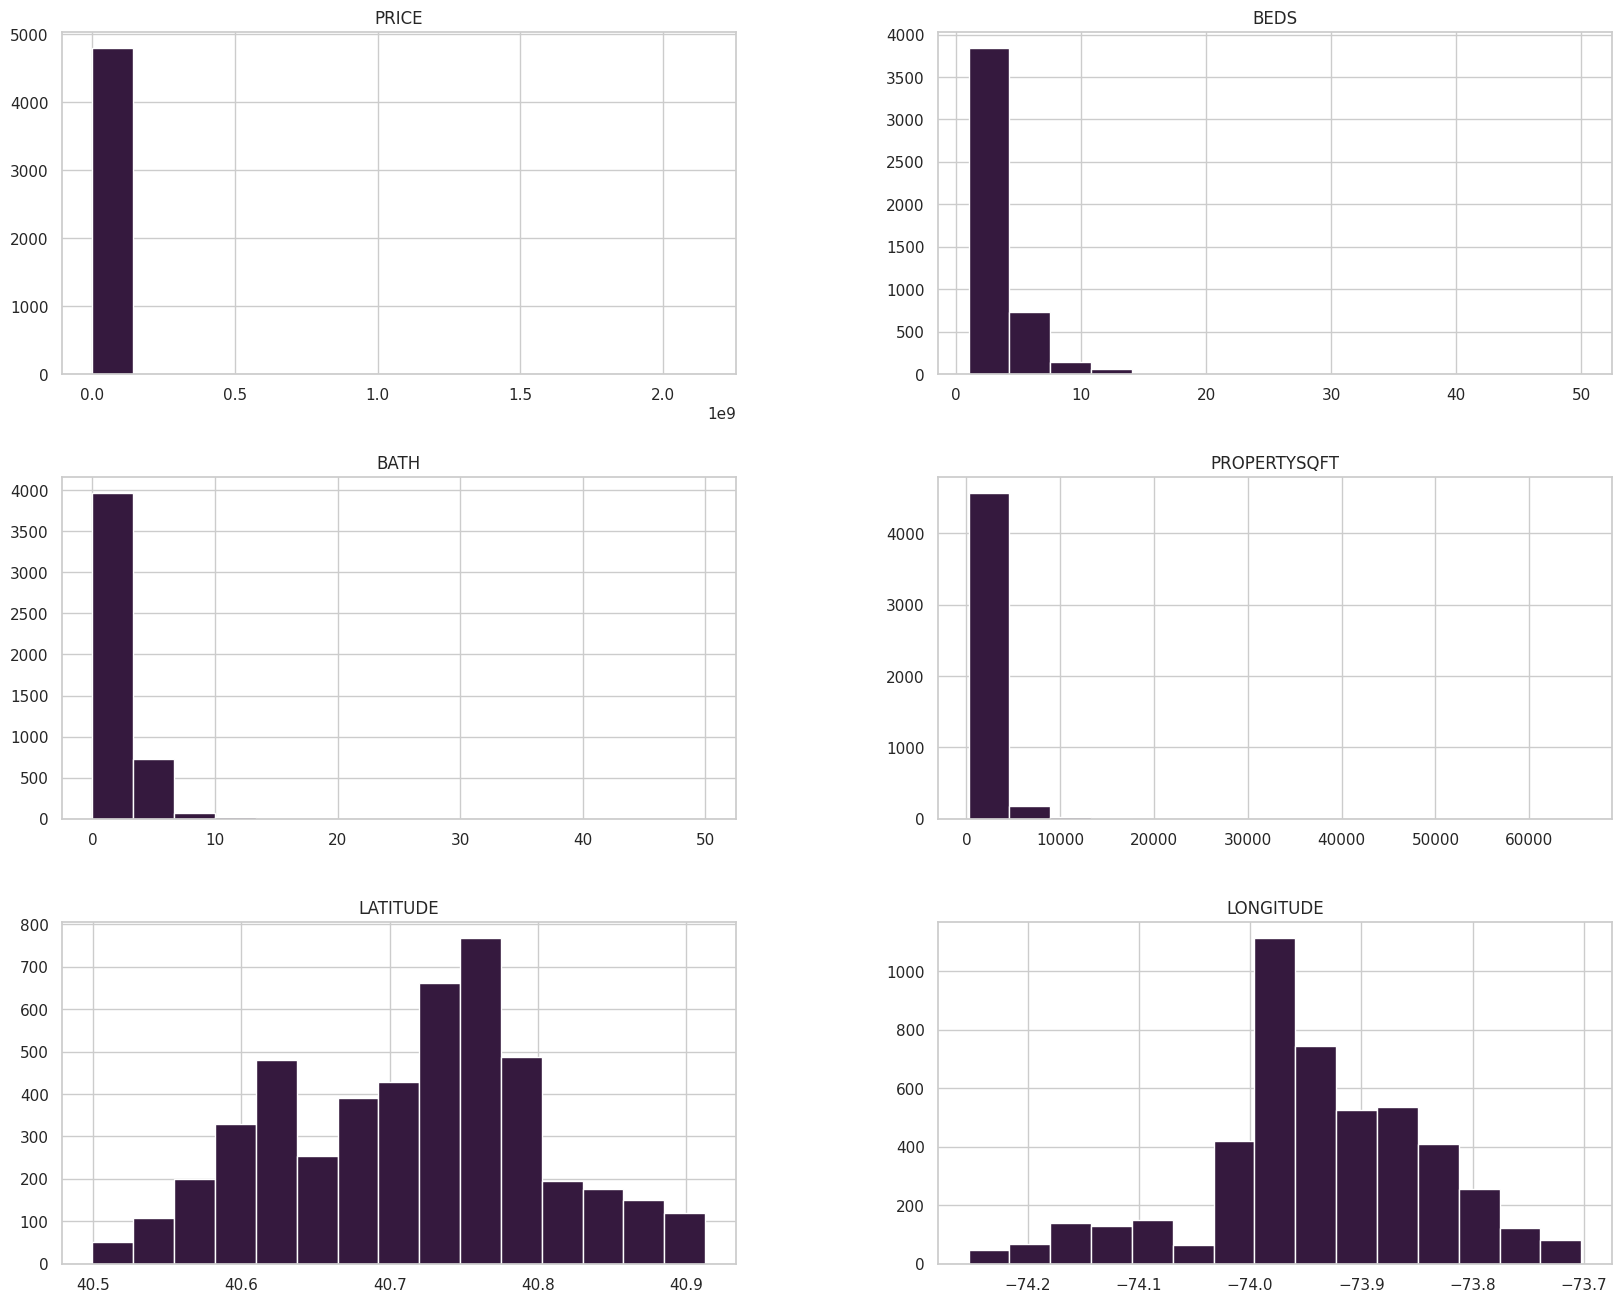

In [11]:
# plotar o histograma das variáveis numéricas
df.hist(bins=15, figsize=(20,16));

# Limpeza dos dados

### Limpando por preços

In [12]:
Q1 = df['PRICE'].quantile(0.25)
Q3 = df['PRICE'].quantile(0.75)

IQR = Q3-Q1

# Valores limites para corte
print(Q1 - 1.5*IQR)
print(Q3 + 1.5*IQR)

-995000.0
2989000.0


In [13]:
# Criando uma cópia do dataset para limpeza
df_clean = df.copy()

# Vou limitar o valor mínimo em 0, já que pelo cáculo foi encontrado um valor negativo.
df_clean.drop(df_clean[df_clean['PRICE'] <= 0].index, axis=0, inplace=True)
# O valor máximo mantenho o cálculo de Q3 + 1.5*IQR
df_clean.drop(df_clean[df_clean['PRICE'] > (Q3 + 1.5*IQR)].index, axis=0, inplace=True)

print(f'O dataset original possui {df.shape[0]} amostras')
print(f'O dataset limpo agora possui {df_clean.shape[0]} amostras')

O dataset original possui 4801 amostras
O dataset limpo agora possui 4242 amostras


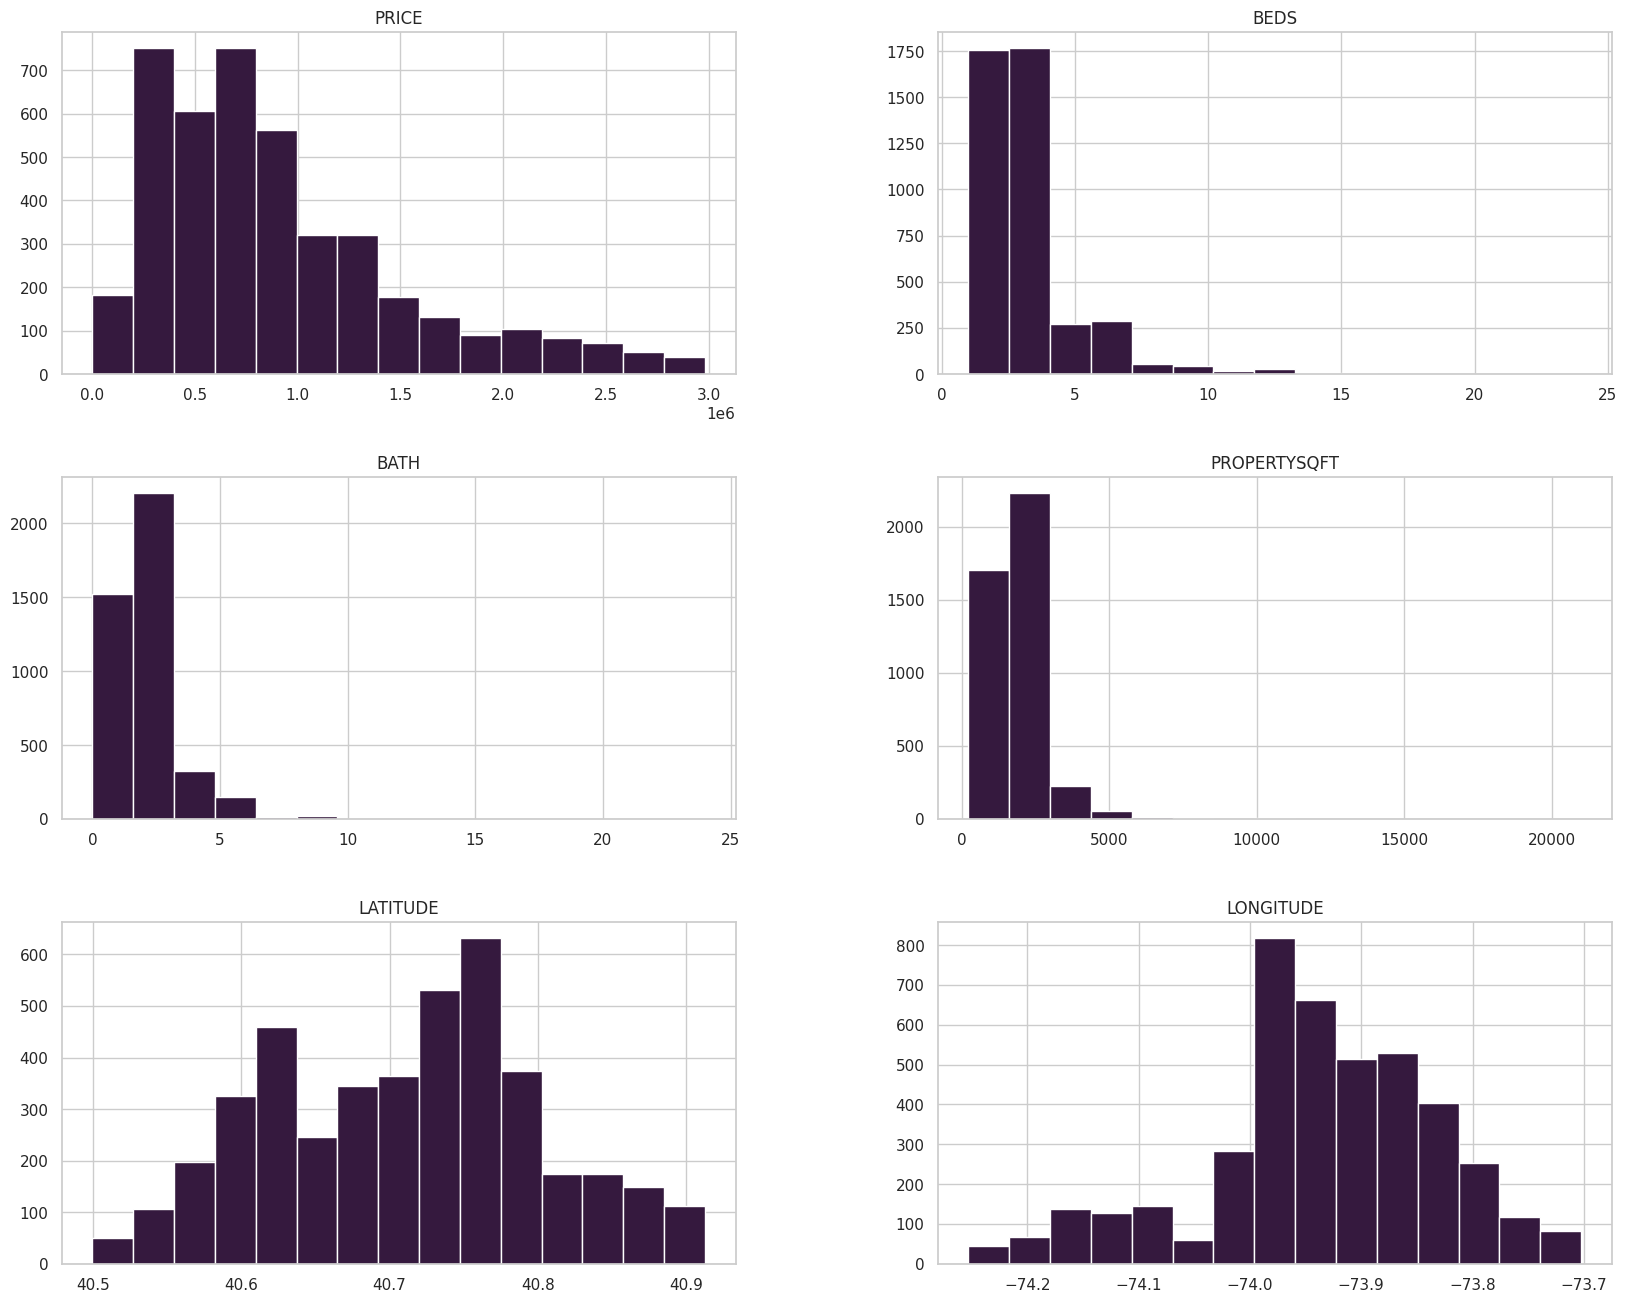

In [14]:
df_clean.hist(bins=15, figsize=(20,16));

### Limpando por área

In [15]:
Q1 = df['PROPERTYSQFT'].quantile(0.25)
Q3 = df['PROPERTYSQFT'].quantile(0.75)

IQR = Q3-Q1

# Valores limites para corte
print(Q1 - 1.5*IQR)
print(Q3 + 1.5*IQR)

-276.3117930000003
3660.5196550000005


In [16]:
# Vou limitar o valor mínimo em 0, já que pelo cáculo foi encontrado um valor negativo.
df_clean.drop(df_clean[df_clean['PROPERTYSQFT'] <= 0].index, axis=0, inplace=True)
# O valor máximo mantenho o cálculo de Q3 + 1.5*IQR
df_clean.drop(df_clean[df_clean['PROPERTYSQFT'] > (Q3 + 1.5*IQR)].index, axis=0, inplace=True)

print(f'O dataset original possui {df.shape[0]} amostras')
print(f'O dataset limpo agora possui {df_clean.shape[0]} amostras')

O dataset original possui 4801 amostras
O dataset limpo agora possui 4090 amostras


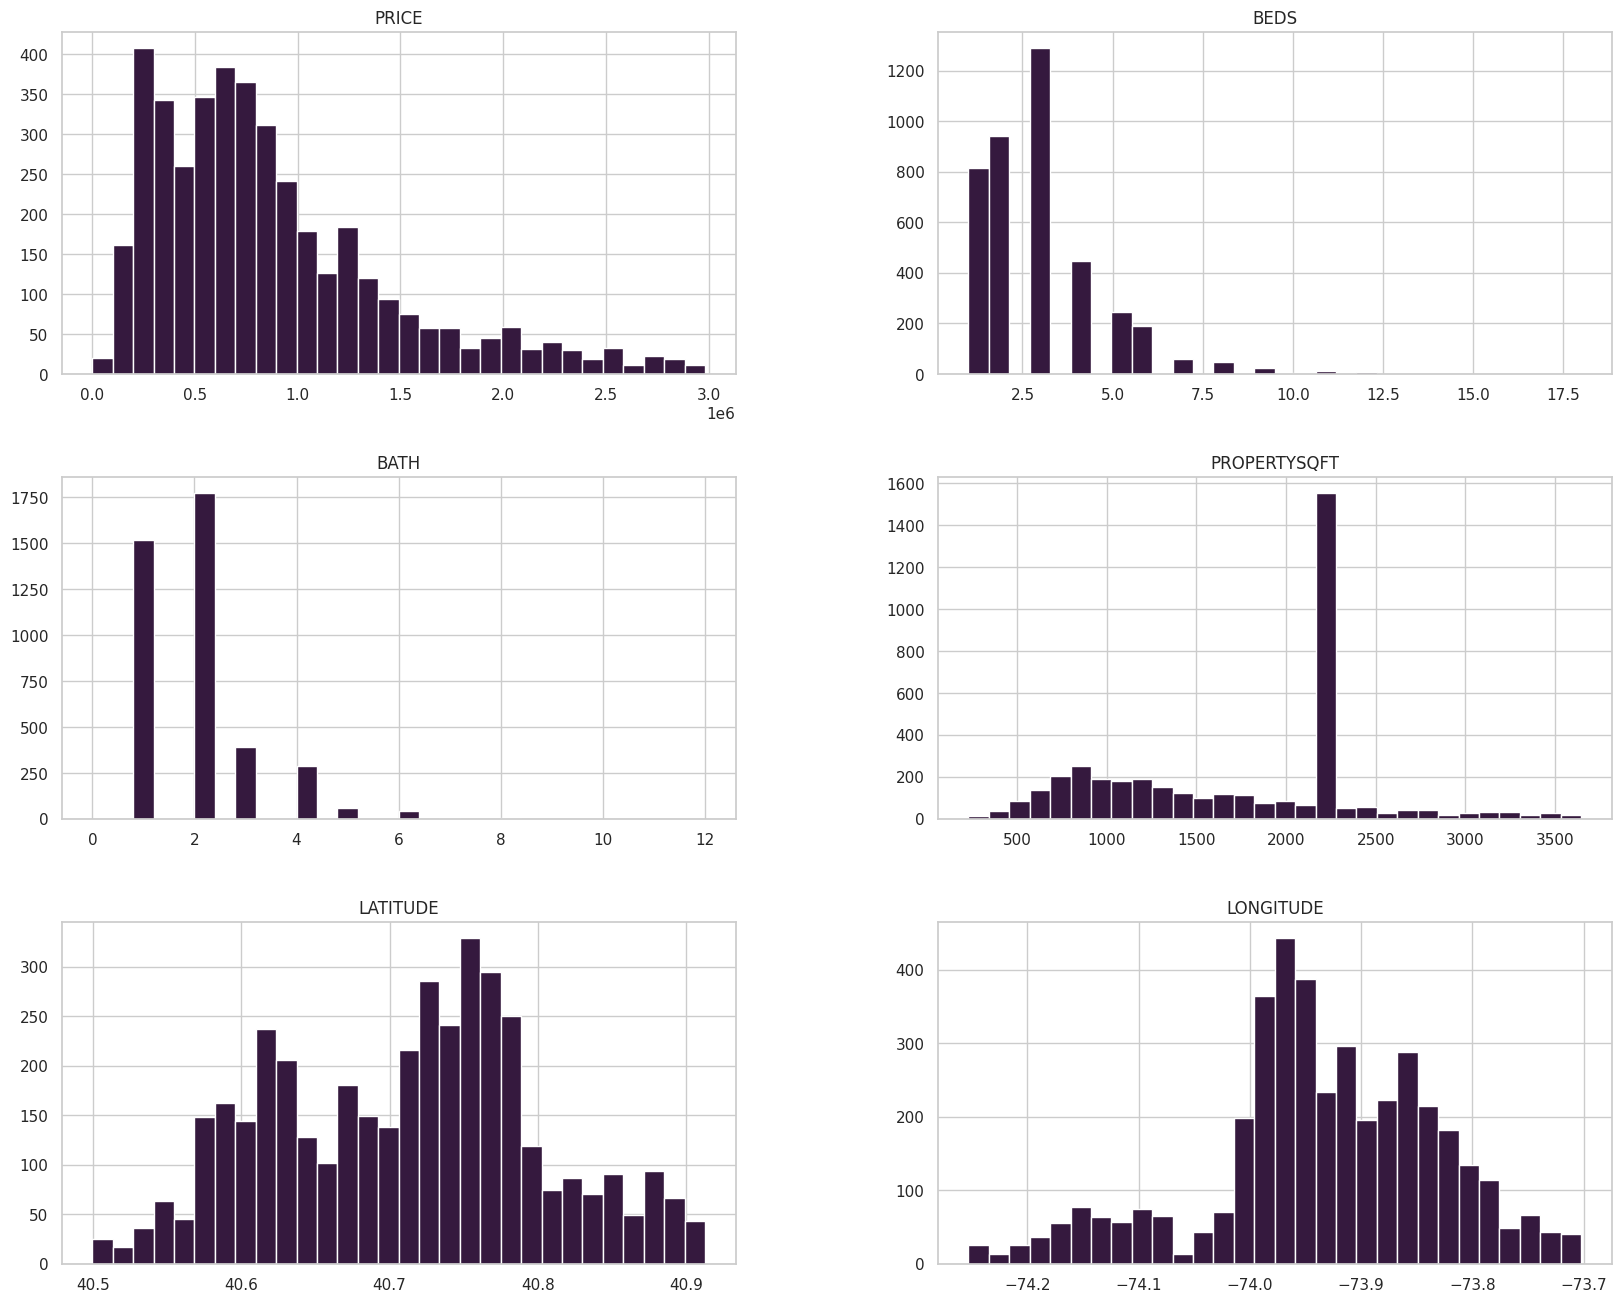

In [17]:
df_clean.hist(bins=30, figsize=(20,16));

In [18]:
df_clean.duplicated().sum()

np.int64(186)

In [19]:
df_clean = df_clean.drop_duplicates()

In [20]:
df_clean.duplicated().sum()

np.int64(0)